## Set-up environment



In [ ]:
!pip install -q transformers torch torchvision matplotlib pillow opencv-python gradio

## Example Radiograph Preparation

The example image used for model evaluation is sourced from the **Bone Tumor X-ray Radiograph Dataset (BTXRD)**.

* **Dataset Title:** A Radiograph Dataset for the Classification, Localization, and Segmentation of Primary Bone Tumors
* **Authors:** Shunhan Yao, Yuanxiang Huang, Xiaoyu Wang, et al.
* **Journal:** Scientific Data (2025)
* **DOI:** https://doi.org/10.1038/s41597-024-04311-y

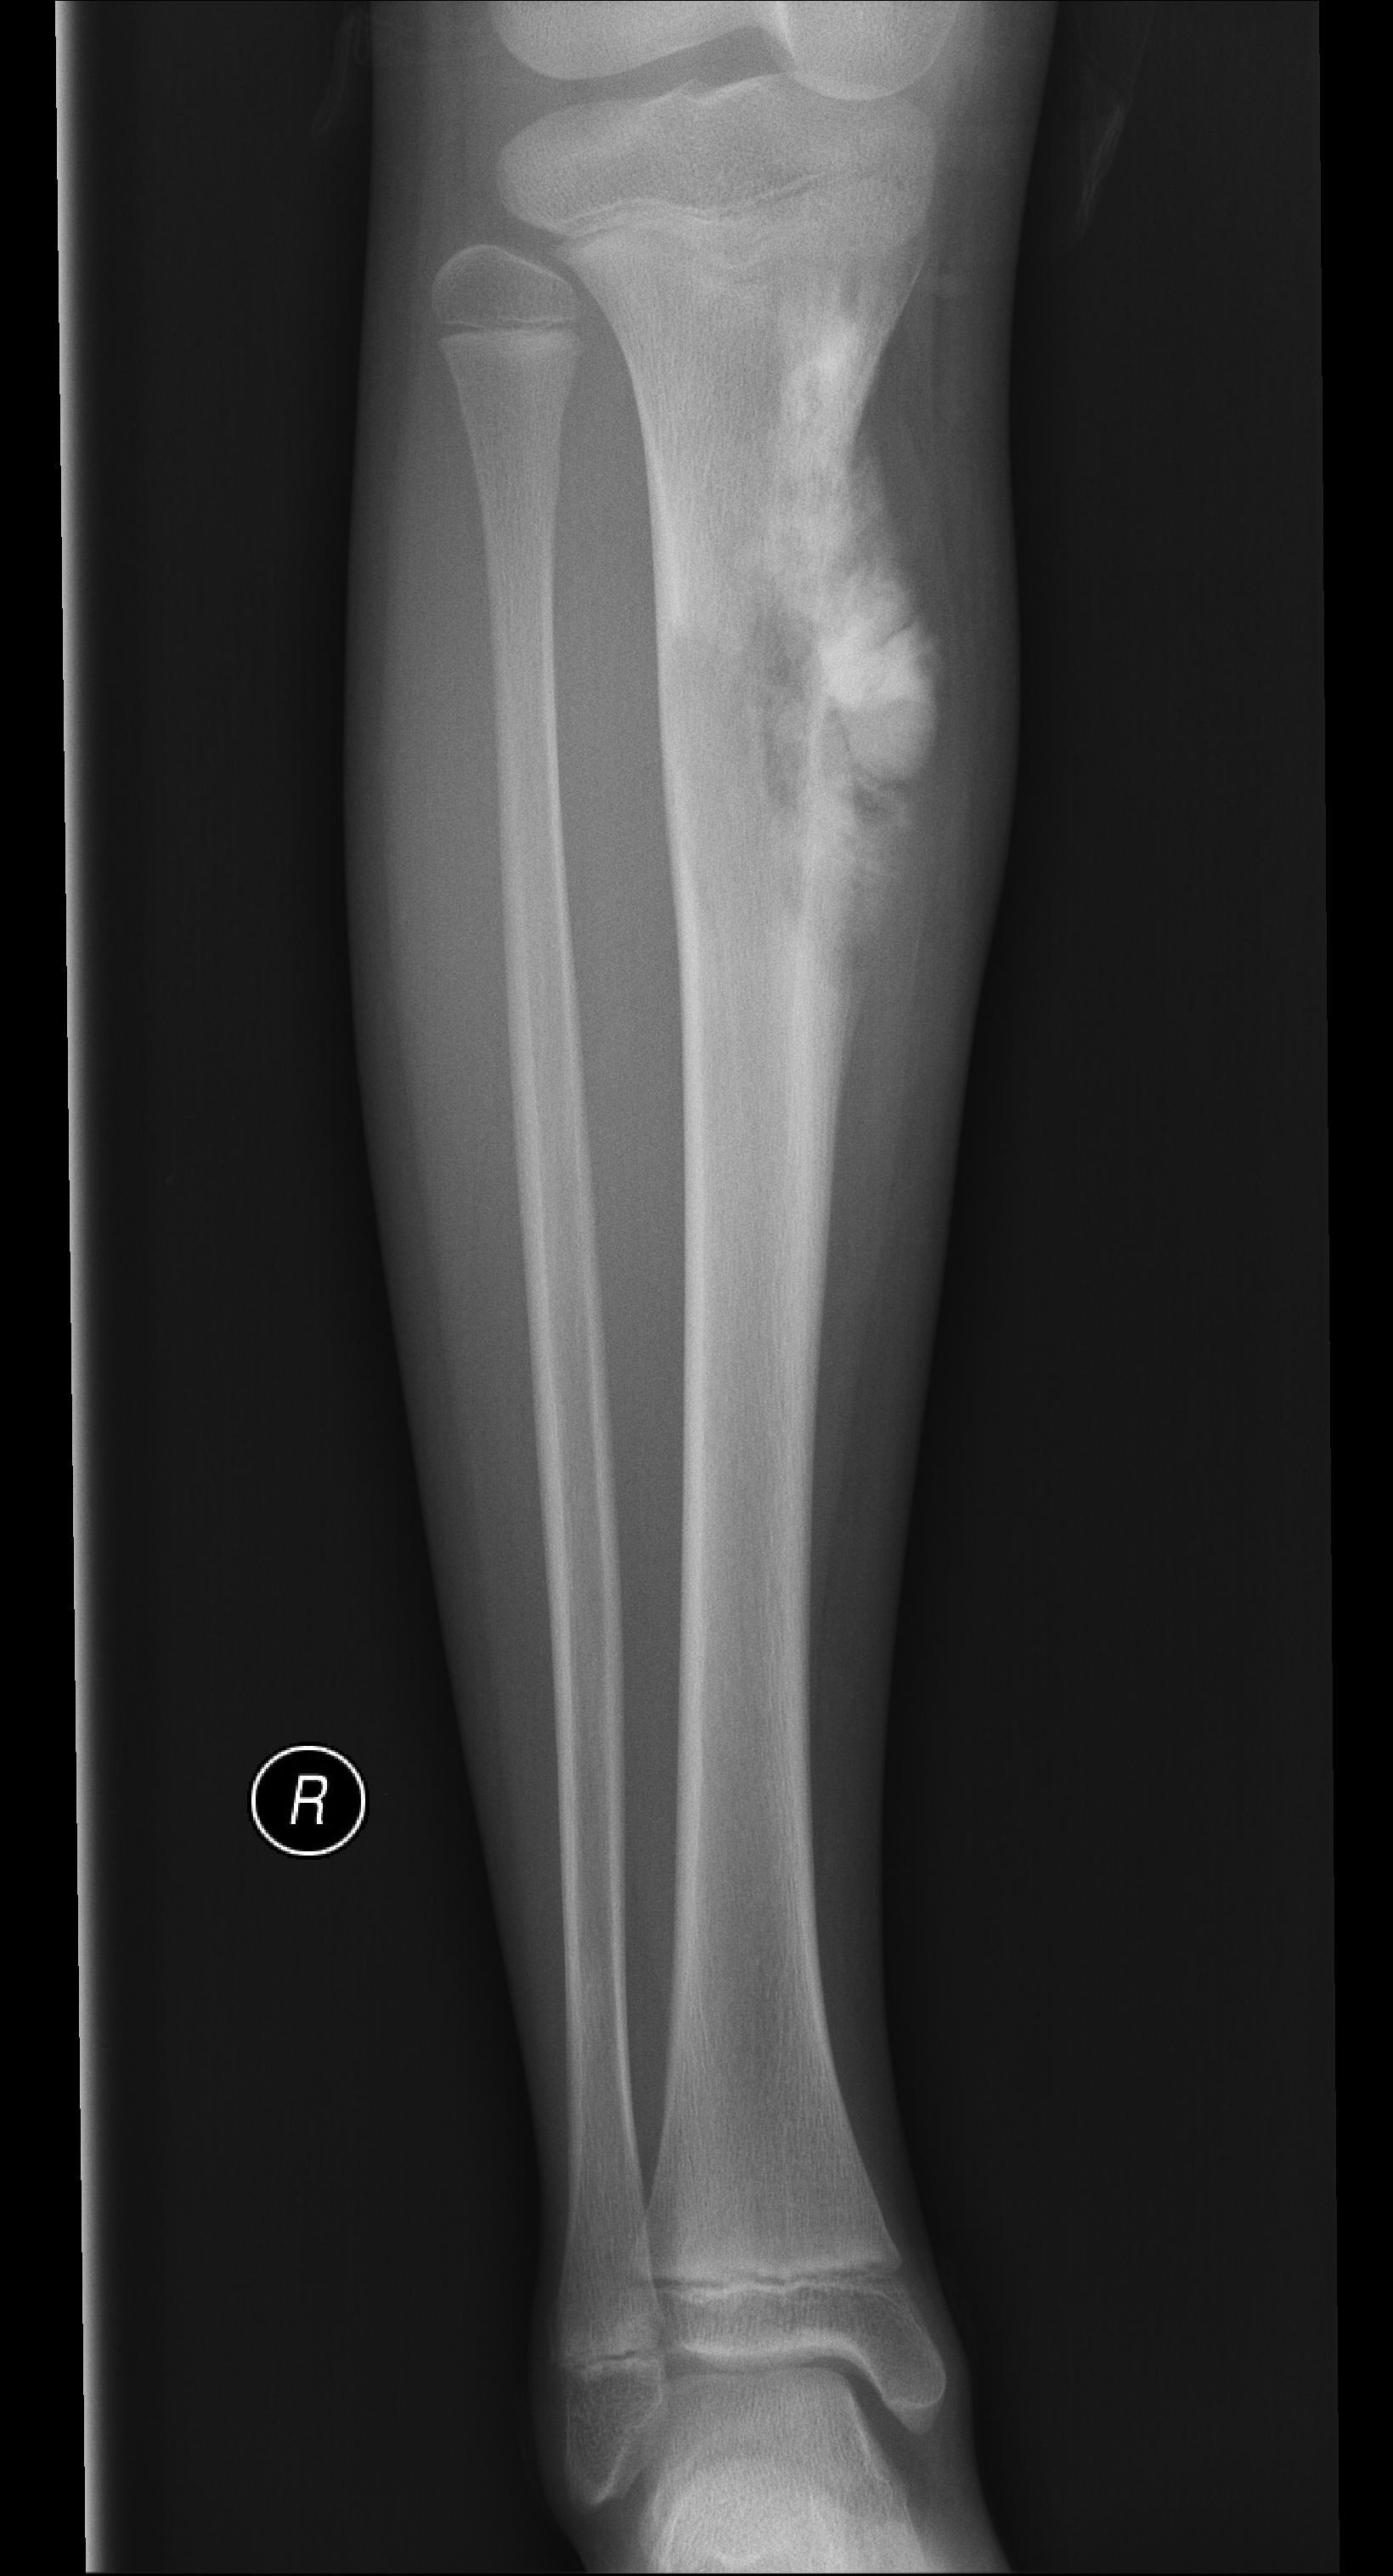

In [ ]:
from PIL import Image
import requests

url = 'https://drive.google.com/uc?export=download&id=1yav38aE_73z2zdZOQR87nenGG_RkRxOW'
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
image




## Downloading SKELEX weights + Creating Model

In [ ]:
from transformers import AutoImageProcessor, ViTMAEForPreTraining

processor = AutoImageProcessor.from_pretrained('skhoha/SKELEX')
model = ViTMAEForPreTraining.from_pretrained('skhoha/SKELEX')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
loss = outputs.loss
mask = outputs.mask
ids_restore = outputs.ids_restore


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/217 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

## Visualization

To visualize the model's reconstruction process, the input pixel values are processed through the following pipeline:

1. **Encoding:** The encoder processes only the visible, unmasked visual patches.
2. **Masking:** Learnable mask tokens are inserted at the positions of the missing patches.
3. **Decoding:** The decoder takes the combined sequence of encoded patches and mask tokens to reconstruct the original pixel values.


- The  code is adapted from the Hugging Face Transformers library (`ViTMAE/ViT_MAE_visualization_demo.ipynb`).
- The methodology is based on the Masked Autoencoders (MAE) architecture by He et al.

In [ ]:

import torch
import numpy as np
import matplotlib.pyplot as plt

imagenet_mean = np.array(processor.image_mean)
imagenet_std = np.array(processor.image_std)

def show_image(image, title=''):
    # image is [H, W, 3]
    if isinstance(image, torch.Tensor):
        image_np = image.detach().cpu().numpy()
    else:
        image_np = image

    denorm = np.clip((image_np * imagenet_std + imagenet_mean) * 255, 0, 255).astype(np.uint8)

    plt.imshow(denorm)
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

def visualize_reconstruction(pixel_values, model):
    # forward pass
    outputs = model(pixel_values)
    y = model.unpatchify(outputs.logits)
    y = torch.einsum('nchw->nhwc', y).detach().cpu()

    # visualize the mask
    mask = outputs.mask.detach()
    mask = mask.unsqueeze(-1).repeat(1, 1, model.config.patch_size**2 *3)  # (N, H*W, p*p*3)
    mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping
    mask = torch.einsum('nchw->nhwc', mask).detach().cpu()

    x = torch.einsum('nchw->nhwc', pixel_values)

    # masked image
    im_masked = x * (1 - mask)

    # SKELEX reconstruction pasted with visible patches
    im_paste = x * (1 - mask) + y * mask

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    titles = [
        "Original Radiograph",
        "Masked Radiograph Input",
        "Reconstructed Radiograph",
        "Reconstructed + Visible Patches"
    ]
    images = [x[0], im_masked[0], y[0], im_paste[0]]

    for i in range(4):
        plt.subplot(1, 4, i + 1)
        show_image(images[i], titles[i])

    plt.show()

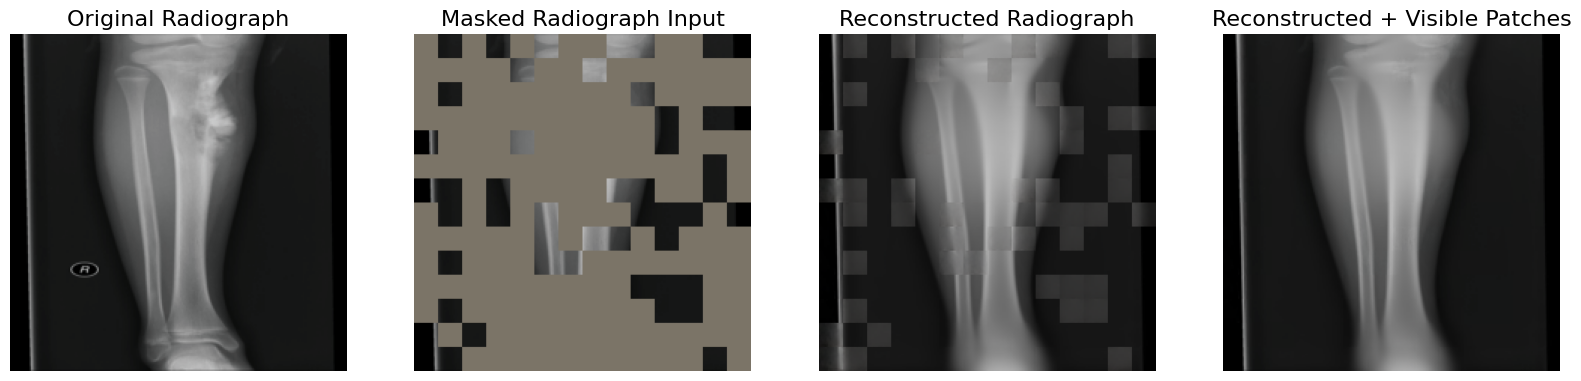

In [ ]:
pixel_values = processor(image, return_tensors="pt").pixel_values
visualize_reconstruction(pixel_values, model)

## Unsupervised Reconstruction-based Anomaly Detection by SKELEX

- **SKELEX** localizes anatomical abnormalities through reconstruction-based error maps. Because the model is trained to reconstruct masked regions of radiographs, any discrepancies between the original and reconstructed images highlight areas that deviate from in-distribution anatomical patterns.

### How It Works: Error Map Generation
The pipeline for generating anomaly maps follows a three-step process:

1. **Mask:** Apply random masking to the input radiograph.
2. **Reconstruct:** Use SKELEX to predict and fill in the masked regions.
3. **Subtract:** Subtract the reconstructed output from the original image to yield the final error map.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from transformers import ViTMAEForPreTraining, AutoImageProcessor
import gradio as gr

class SKELEXVisTool:
    def __init__(self, model_id):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Loading model: {model_id} on {self.device}...")

        # Load from Hugging Face or local path
        self.model = ViTMAEForPreTraining.from_pretrained(model_id).to(self.device).eval()
        self.processor = AutoImageProcessor.from_pretrained(model_id)

    @torch.no_grad()
    def process(self, pil_img, n_passes=10, alpha=0.5):
        # Preprocess
        inputs = self.processor(images=pil_img, return_tensors="pt").to(self.device)
        pixel_values = inputs["pixel_values"]

        # Batch processing for speed (repeat image N times)
        batch_pixels = pixel_values.repeat(n_passes, 1, 1, 1)
        outputs = self.model(batch_pixels)

        # Reconstruction
        rec = self.model.unpatchify(outputs.logits)
        mask = outputs.mask.detach().unsqueeze(-1).repeat(1, 1, self.model.config.patch_size**2 * 3)
        mask = self.model.unpatchify(mask)

        # Calculate Error Map (MSE)
        diff = (rec - batch_pixels) ** 2
        error_map = (diff * mask).mean(dim=0).permute(1, 2, 0).cpu().numpy()

        # Normalize heatmap
        heatmap = np.mean(error_map, axis=-1)
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        # Create Plot
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(pil_img)

        # Extract original dimensions to map the heatmap coordinate space perfectly
        width, height = pil_img.size
        im = ax.imshow(heatmap, cmap='hot', alpha=alpha, extent=[0, width, height, 0])

        ax.axis('off')
        plt.colorbar(im, ax=ax, label="Reconstruction Error (Anomaly Score)")

        return fig

# Initialize Tool
tool = SKELEXVisTool("skhoha/SKELEX")

Loading model: skhoha/SKELEX on cuda...


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [ ]:
def inference(image, passes, opacity):
    return tool.process(image, n_passes=passes, alpha=opacity)

demo = gr.Interface(
    fn=inference,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Slider(1, 50, value=10, step=1, label="Number of Passes"),
        gr.Slider(0, 1, value=0.5, label="Heatmap Opacity")
    ],
    outputs=gr.Plot(label="SKELEX Error Map Visualization"),
    title="SKELEX Unsupervised Anomaly Detector",
    description="Upload an image to see where the SKELEX struggles to reconstruct pixels. Higher error usually indicates anomalous features."
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ff2f263c3b232ef827.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ff2f263c3b232ef827.gradio.live


## Fine-tuning SKELEX

You can directly load the weights of the SKELEX encoder into a `ViTForImageClassification` and start fine-tuning. There will be a warning that the weights of the decoder will not be used.

In [ ]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained("skhoha/SKELEX")

You are using a model of type vit_mae to instantiate a model of type vit. This is not supported for all configurations of models and can yield errors.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: skhoha/SKELEX
Key                                                                              | Status     | 
---------------------------------------------------------------------------------+------------+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.bias      | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.bias          | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.weight           | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.bias                | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.key.weight   | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.weight              | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.bias            | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.we